# 🧪 Starter Notebook: Predict Melting Point


This notebook provides a baseline for the competition on predicting **melting point (Tm)** of compounds.

We use:
- Exploratory Data Analysis (EDA)
- Baseline linear regression
- Tree-based model (XGBoost)
- Evaluation with MAE on Tm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import xgboost as xgb

# Load data
url = 'https://apmonitor.com/pds/uploads/Main/'
train = pd.read_csv(url+'melt_train.csv')
test = pd.read_csv(url+'melt_test.csv')
print(train.shape, test.shape)
train.head()

(2662, 427) (666, 426)


,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


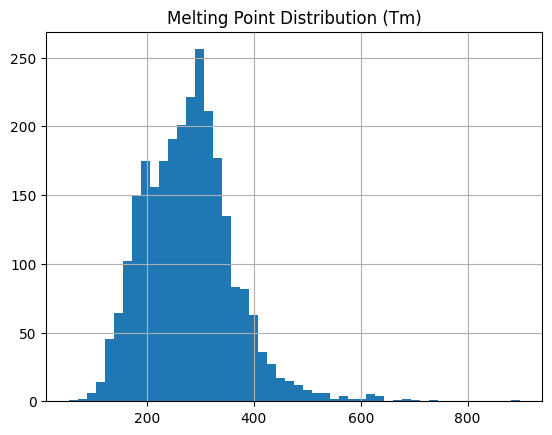

In [2]:
# Distribution of targets
train['Tm'].hist(bins=50)
ax = plt.gca()
ax.set_title("Melting Point Distribution (Tm)")
plt.show()

In [3]:
X = train.drop(columns=['id','SMILES','Tm'])
y = train['Tm']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
tm_pred = lr.predict(X_val)
lr_mae = mean_absolute_error(y_val, tm_pred)

print("Linear Regression MAE Tm:", lr_mae)

Linear Regression MAE Tm: 36.90470528219311


In [5]:
xgb_tm = xgb.XGBRegressor(tree_method='hist', n_estimators=300)
xgb_tm.fit(X_train, y_train)
tm_pred = xgb_tm.predict(X_val)
xgb_tm_mae = mean_absolute_error(y_val, tm_pred)

print("XGBoost MAE Tm:", xgb_tm_mae)

XGBoost MAE Tm: 33.56784282118921


In [6]:
# Train simple model on full training data (LightGBM as example)
X_full = train.drop(columns=['id','SMILES','Tm'])
y_full = train['Tm']

xgb_tm = xgb.XGBRegressor(tree_method='hist', n_estimators=300)
xgb_tm.fit(X_full, y_full)

X_test = test.drop(columns=['id','SMILES'])
pred_tm = xgb_tm.predict(X_test)

submission = test[['id']].copy()
submission['Tm'] = pred_tm
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Tm
0,1022,340.440033
1,1146,316.701324
2,79,218.831696
3,2279,218.053513
4,1342,230.530930
